# Customer Churn Prediction

## 1. Data Loading and Initial Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load the dataset
df = pd.read_csv('/content/ecomm.csv')

# Display the first 5 rows of the DataFrame
print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,order_id,customer_id,age,product_id,country,signup_date,last_purchase_date,cancellations_count,subscription_status,order_date,unit_price,quantity,purchase_frequency,preferred_category,product_name,category,gender
0,ORD5000,CUST1000,39,PROD200,Canada,01-07-2021,2/21/2023,0,active,8/20/2024,78.21,5,37,Sports,Football,Sports,Female
1,ORD5001,CUST1001,61,PROD201,USA,10/19/2020,12-08-2021,0,active,7/17/2025,64.02,8,35,Sports,Refrigerator,Home,Female
2,ORD5002,CUST1002,26,PROD202,Pakistan,06-10-2023,09-04-2023,3,cancelled,03-12-2025,604.14,2,44,Electronics,Hoodie,Clothing,Female
3,ORD5003,CUST1003,54,PROD203,India,7/30/2023,2/20/2024,4,paused,9/19/2024,84.66,4,1,Sports,Conditioner,Beauty,Male
4,ORD5004,CUST1004,50,PROD204,India,12-09-2020,9/14/2024,0,active,08-08-2024,62.66,7,35,Sports,Smartwatch,Electronics,Male


In [2]:
# Display basic information about the DataFrame
print("\nDataFrame Info:")
df.info()


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   order_id             2000 non-null   object 
 1   customer_id          2000 non-null   object 
 2   age                  2000 non-null   int64  
 3   product_id           2000 non-null   object 
 4   country              2000 non-null   object 
 5   signup_date          2000 non-null   object 
 6   last_purchase_date   2000 non-null   object 
 7   cancellations_count  2000 non-null   int64  
 8   subscription_status  2000 non-null   object 
 9   order_date           2000 non-null   object 
 10  unit_price           2000 non-null   float64
 11  quantity             2000 non-null   int64  
 12  purchase_frequency   2000 non-null   int64  
 13  preferred_category   2000 non-null   object 
 14  product_name         2000 non-null   object 
 15  category             

In [3]:
# Display descriptive statistics
print("\nDescriptive Statistics:")
display(df.describe(include='all'))


Descriptive Statistics:


,order_id,customer_id,age,product_id,country,signup_date,last_purchase_date,cancellations_count,subscription_status,order_date,unit_price,quantity,purchase_frequency,preferred_category,product_name,category,gender
count,2000,2000,2000.000000,2000,2000,2000,2000,2000.000000,2000,2000,2000.000000,2000.000000,2000.000000,2000,2000,2000,2000
unique,2000,2000,NaN,2000,6,926,1078,NaN,3,1106,NaN,NaN,NaN,5,40,5,3
top,ORD6983,CUST2983,NaN,PROD2183,Germany,04-10-2023,11/30/2023,NaN,active,4/24/2024,NaN,NaN,NaN,Clothing,Sneakers,Clothing,Female
freq,1,1,NaN,1,360,8,7,NaN,1204,7,NaN,NaN,NaN,419,72,426,1015
mean,NaN,NaN,44.080500,NaN,NaN,NaN,NaN,2.441500,NaN,NaN,324.719460,4.948500,25.158000,NaN,NaN,NaN,NaN
std,NaN,NaN,14.798091,NaN,NaN,NaN,NaN,1.702359,NaN,NaN,361.548405,2.557757,14.158752,NaN,NaN,NaN,NaN
min,NaN,NaN,18.000000,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,2.850000,1.000000,1.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,31.000000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,111.127500,3.000000,13.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,45.000000,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,206.515000,5.000000,25.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,57.000000,NaN,NaN,NaN,NaN,4.000000,NaN,NaN,384.507500,7.000000,37.000000,NaN,NaN,NaN,NaN


In [4]:
# Check for missing values
print("\nMissing Values:")
display(df.isnull().sum())


Missing Values:


,0
order_id,0
customer_id,0
age,0
product_id,0
country,0
signup_date,0
last_purchase_date,0
cancellations_count,0
subscription_status,0
order_date,0


## 2. Data Preprocessing

In [5]:
# Handle missing values
# For simplicity, let's fill numerical missing values with the mean and categorical with the mode
for column in df.columns:
    if df[column].dtype == 'object':
        # Fill categorical missing values with the mode
        df[column].fillna(df[column].mode()[0], inplace=True)
    else:
        # Fill numerical missing values with the mean
        df[column].fillna(df[column].mean(), inplace=True)

print("\nMissing Values after imputation:")
display(df.isnull().sum())


Missing Values after imputation:


/tmp/ipykernel_4561/1573072727.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(df[column].mode()[0], inplace=True)
/tmp/ipykernel_4561/1573072727.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)',

,0
order_id,0
customer_id,0
age,0
product_id,0
country,0
signup_date,0
last_purchase_date,0
cancellations_count,0
subscription_status,0
order_date,0


In [6]:
# Encode categorical features
# Identify categorical columns
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

print("\nDataFrame after encoding categorical features:")
display(df.head())


DataFrame after encoding categorical features:


,order_id,customer_id,age,product_id,country,signup_date,last_purchase_date,cancellations_count,subscription_status,order_date,unit_price,quantity,purchase_frequency,preferred_category,product_name,category,gender
0,0,0,39,1000,0,13,657,0,0,1022,78.21,5,37,4,12,4,0
1,1,1,61,1011,5,371,570,0,0,940,64.02,8,35,4,26,3,0
2,2,2,26,1022,3,173,299,3,1,113,604.14,2,44,2,16,1,0
3,3,3,54,1033,2,830,655,4,2,1073,84.66,4,1,4,5,0,1
4,4,4,50,1044,2,490,1036,0,0,292,62.66,7,35,4,32,2,1


## 3. Model Building and Evaluation

In [11]:
# Define features (X) and target (y)
# The main aim is to predict if the consumer will churn or not,
# so 'subscription_status' is the most appropriate target column.
# 'cancelled' indicates churn.

# Based on previous LabelEncoding in cell a6b9cff3, we observed the mapping:
# active -> 0
# cancelled -> 1
# paused -> 2
# So, subscription_status == 1 means 'cancelled' (churn).

df['churn_target'] = (df['subscription_status'] == 1).astype(int)

# Drop original 'subscription_status' (as it's now represented by 'churn_target')
# and 'churn_target' itself from the features DataFrame X.
# We will keep 'gender' as a feature, assuming it might be relevant to churn prediction.
X = df.drop(columns=['churn_target', 'subscription_status'])
y = df['churn_target']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) # stratify for imbalanced classes

print(f"\nShape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")


Shape of X_train: (1600, 16)
Shape of X_test: (400, 16)
Shape of y_train: (1600,)
Shape of y_test: (400,)


In [12]:
# Scale numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeatures scaled.")


Features scaled.


In [13]:
# Train a Logistic Regression model
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

print("\nLogistic Regression model trained.")


Logistic Regression model trained.



Model Accuracy: 0.7525

Classification Report:
              precision    recall  f1-score   support

           0       0.75      1.00      0.86       301
           1       0.00      0.00      0.00        99

    accuracy                           0.75       400
   macro avg       0.38      0.50      0.43       400
weighted avg       0.57      0.75      0.65       400


Confusion Matrix:
[[301   0]
 [ 99   0]]


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


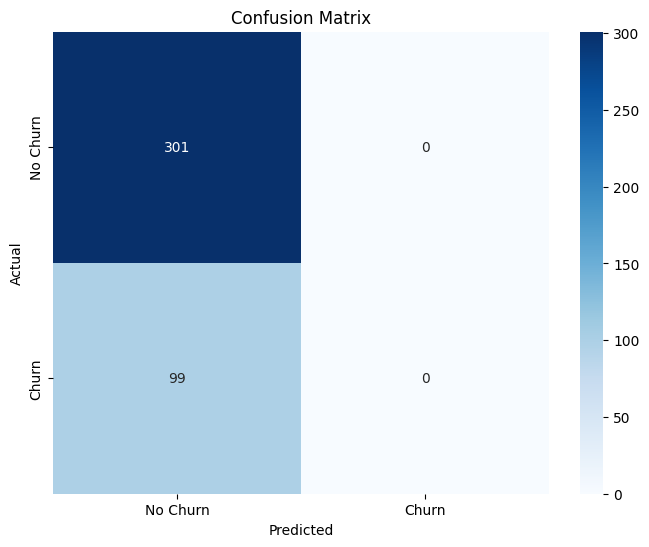

In [14]:
# Make predictions on the test set
y_pred = model.predict(X_test_scaled)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"\nModel Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(report)
print("\nConfusion Matrix:")
print(conf_matrix)

# Visualize the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 4. Addressing Class Imbalance with SMOTE

In [15]:
from imblearn.over_sampling import SMOTE

print("Original training set shape:", X_train.shape, y_train.shape)
print("Original 'Churn' count in training set:", y_train.value_counts()[1])
print("Original 'No Churn' count in training set:", y_train.value_counts()[0])

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train)

print("\nResampled training set shape:", X_train_res.shape, y_train_res.shape)
print("Resampled 'Churn' count in training set:", y_train_res.value_counts()[1])
print("Resampled 'No Churn' count in training set:", y_train_res.value_counts()[0])

Original training set shape: (1600, 16) (1600,)
Original 'Churn' count in training set: 394
Original 'No Churn' count in training set: 1206

Resampled training set shape: (2412, 16) (2412,)
Resampled 'Churn' count in training set: 1206
Resampled 'No Churn' count in training set: 1206


## 5. Model Training and Evaluation after SMOTE

In [16]:
# Train a Logistic Regression model on the resampled data
model_smote = LogisticRegression(random_state=42)
model_smote.fit(X_train_res, y_train_res)

print("\nLogistic Regression model trained with SMOTE data.")


Logistic Regression model trained with SMOTE data.



Model Accuracy (with SMOTE): 0.4900

Classification Report (with SMOTE):
              precision    recall  f1-score   support

           0       0.73      0.51      0.60       301
           1       0.22      0.41      0.29        99

    accuracy                           0.49       400
   macro avg       0.47      0.46      0.44       400
weighted avg       0.60      0.49      0.52       400


Confusion Matrix (with SMOTE):
[[155 146]
 [ 58  41]]

AUC-ROC Score (with SMOTE): 0.4500


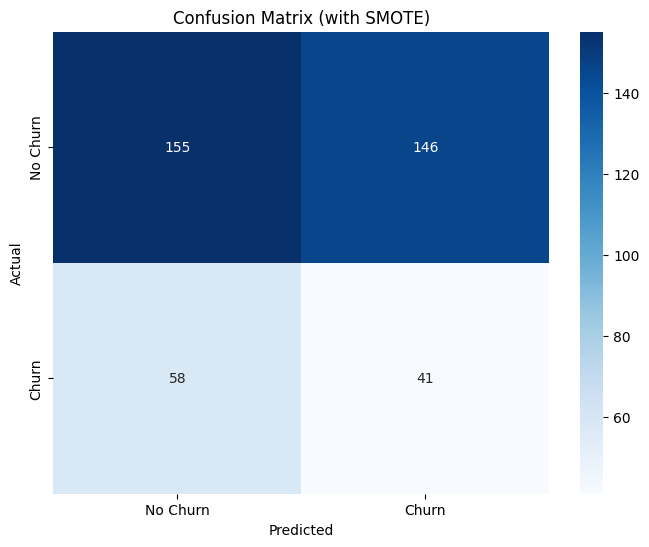

In [17]:
# Make predictions on the original (unresampled) test set
y_pred_smote = model_smote.predict(X_test_scaled)
y_pred_proba_smote = model_smote.predict_proba(X_test_scaled)[:, 1] # Get probabilities for the positive class (Churn)

# Evaluate the model
accuracy_smote = accuracy_score(y_test, y_pred_smote)
report_smote = classification_report(y_test, y_pred_smote)
conf_matrix_smote = confusion_matrix(y_test, y_pred_smote)

from sklearn.metrics import roc_auc_score
auc_roc_smote = roc_auc_score(y_test, y_pred_proba_smote)

print(f"\nModel Accuracy (with SMOTE): {accuracy_smote:.4f}")
print("\nClassification Report (with SMOTE):")
print(report_smote)
print("\nConfusion Matrix (with SMOTE):")
print(conf_matrix_smote)
print(f"\nAUC-ROC Score (with SMOTE): {auc_roc_smote:.4f}")

# Visualize the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_smote, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix (with SMOTE)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 6. Training and Evaluating a Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train a Random Forest Classifier using the SMOTE-resampled data
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_res, y_train_res)

print("\nRandom Forest Classifier trained with SMOTE data.")

In [ ]:
# Make predictions on the original (unresampled) test set
y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1] # Get probabilities for the positive class (Churn)

# Evaluate the Random Forest model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
report_rf = classification_report(y_test, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
auc_roc_rf = roc_auc_score(y_test, y_pred_proba_rf)

print(f"\nRandom Forest Model Accuracy: {accuracy_rf:.4f}")
print("\nRandom Forest Classification Report:")
print(report_rf)
print("\nRandom Forest Confusion Matrix:")
print(conf_matrix_rf)
print(f"\nRandom Forest AUC-ROC Score: {auc_roc_rf:.4f}")

# Visualize the Confusion Matrix for Random Forest
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix (Random Forest with SMOTE)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()